# Heart Disease Classification Report

This notebook evaluates the existing heart sound classifier using report-grade metrics beyond accuracy. It computes precision, recall, F1-score, specificity, ROC-AUC, confusion matrices, ROC and precision-recall curves, class distribution plots, and explainability figures that can be used in a project report.

In [4]:
from pathlib import Path
import warnings

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.pipeline import make_pipeline

from gradcam import get_gradcam, get_last_conv_layer_name, save_superimposed_gradcam
from utils import preprocess_audio

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

print("Libraries loaded.")

Libraries loaded.


## 1. Load Libraries and Dataset

The project uses an audio dataset organized into class folders. The notebook maps the dataset onto the model's four-class label space: Normal, Murmur, Extrastole, and Artifact. Any extra folders are left out of model scoring so the evaluation stays consistent with the trained classifier.

In [5]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "dataset" / "Heartbeat_Sound_balanced_custom"
MODEL_DIR = BASE_DIR / "models"
REPORT_DIR = BASE_DIR / "static" / "report_images"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

LABELS = ["Normal", "Murmur", "Extrastole", "Artifact"]
LABEL_TO_INDEX = {label: idx for idx, label in enumerate(LABELS)}
DATASET_FOLDERS = {
    "normal": "Normal",
    "murmur": "Murmur",
    "extrastole": "Extrastole",
    "artifact": "Artifact",
}
RANDOM_STATE = 42
MAX_SAMPLES_PER_CLASS = None  # Set to an integer to speed up evaluation on a smaller subset

records = []
folder_counts = []
for folder in sorted(DATA_DIR.iterdir()):
    if not folder.is_dir():
        continue
    wav_files = sorted(folder.glob("*.wav"))
    folder_counts.append({"folder": folder.name, "files": len(wav_files)})
    if folder.name in DATASET_FOLDERS:
        for wav_file in wav_files:
            records.append(
                {
                    "path": wav_file,
                    "label": DATASET_FOLDERS[folder.name],
                    "folder": folder.name,
                }
            )

df = pd.DataFrame(records)
folder_counts_df = pd.DataFrame(folder_counts).sort_values("folder")

print(f"Dataset root: {DATA_DIR}")
print(f"Evaluation samples mapped to model classes: {len(df)}")
display(folder_counts_df)
display(df.head())

Dataset root: /Users/swarup/Downloads/heart_app/dataset/Heartbeat_Sound_balanced_custom
Evaluation samples mapped to model classes: 1847


,folder,files
0,artifact,297
1,extrahls,300
2,extrastole,300
3,murmur,300
4,normal,950


,path,label,folder
0,/Users/swarup/Downloads/heart_app/dataset/Hear...,Artifact,artifact
1,/Users/swarup/Downloads/heart_app/dataset/Hear...,Artifact,artifact
2,/Users/swarup/Downloads/heart_app/dataset/Hear...,Artifact,artifact
3,/Users/swarup/Downloads/heart_app/dataset/Hear...,Artifact,artifact
4,/Users/swarup/Downloads/heart_app/dataset/Hear...,Artifact,artifact


Train samples: 1477
Test samples: 370


label
Normal        190
Murmur         60
Extrastole     60
Artifact       60
Name: count, dtype: int64

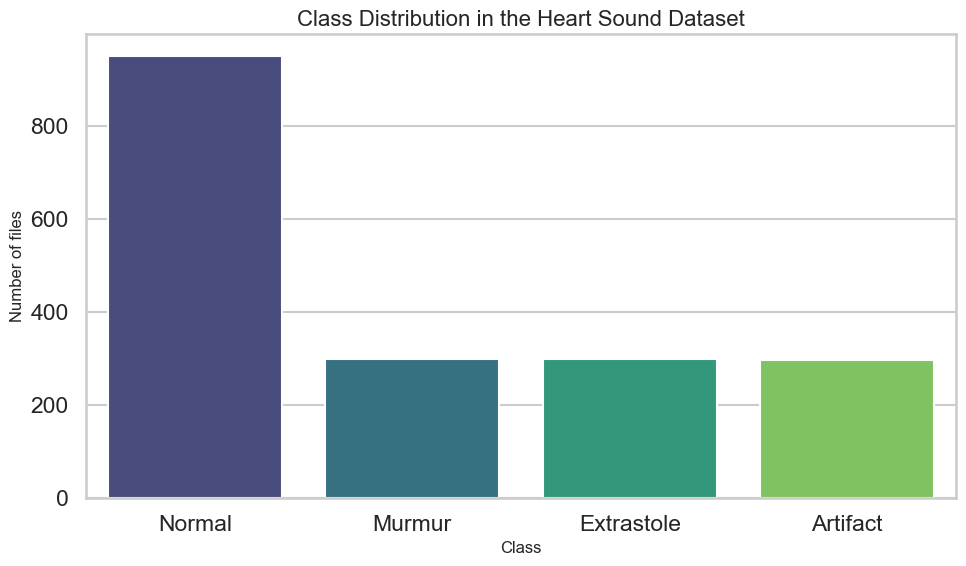

Saved: /Users/swarup/Downloads/heart_app/static/report_images/class_distribution.png


In [6]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

if MAX_SAMPLES_PER_CLASS is not None:
    test_df = (
        test_df.groupby("label", group_keys=False)
        .apply(lambda group: group.sample(min(len(group), MAX_SAMPLES_PER_CLASS), random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )

print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
display(test_df["label"].value_counts().reindex(LABELS))

fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df, x="label", order=LABELS, palette="viridis", ax=ax)
ax.set_title("Class Distribution in the Heart Sound Dataset")
ax.set_xlabel("Class")
ax.set_ylabel("Number of files")
plt.tight_layout()
class_dist_path = REPORT_DIR / "class_distribution.png"
fig.savefig(class_dist_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {class_dist_path}")

## 2. Preprocess Heart Sound Inputs and Generate Predictions

The trained TensorFlow models operate on the same 2-second Mel-spectrogram representation used by the web app. The notebook reuses the project's preprocessing pipeline so the metrics match the deployed system.

In [7]:
binary_model = tf.keras.models.load_model(MODEL_DIR / "final_cnn_transformer_binary.keras", compile=False)
sub_model = tf.keras.models.load_model(MODEL_DIR / "final_cnn_transformer_subclass.keras", compile=False)


def predict_audio_file(file_path):
    """Return model probabilities and labels for a single audio file."""
    input_tensor = preprocess_audio(str(file_path))
    binary_prob = float(binary_model.predict(input_tensor, verbose=0)[0][0])
    subclass_probs = sub_model.predict(input_tensor, verbose=0)[0]
    pred_idx = int(np.argmax(subclass_probs))
    pred_label = LABELS[pred_idx]
    final_label = "Normal" if pred_label == "Normal" else "Abnormal"
    return {
        "binary_prob": binary_prob,
        "subclass_probs": subclass_probs,
        "pred_idx": pred_idx,
        "pred_label": pred_label,
        "final_label": final_label,
    }


def evaluate_frame(frame):
    rows = []
    for item in frame.itertuples(index=False):
        output = predict_audio_file(item.path)
        rows.append(
            {
                "path": item.path,
                "label": item.label,
                "y_true_idx": LABEL_TO_INDEX[item.label],
                "y_pred_idx": output["pred_idx"],
                "y_pred_label": output["pred_label"],
                "binary_prob": output["binary_prob"],
                "final_label": output["final_label"],
                "subclass_probs": output["subclass_probs"],
            }
        )
    return pd.DataFrame(rows)

print("Models loaded and prediction helpers are ready.")

Models loaded and prediction helpers are ready.


## 3. Compute Classification Metrics

This section evaluates the classifier on a stratified test split and reports class-level and aggregate metrics. Specificity is derived from the confusion matrix so the report captures how well each class is rejected when it is absent.

In [8]:
eval_df = evaluate_frame(test_df).reset_index(drop=True)

print(f"Evaluated files: {len(eval_df)}")
display(eval_df.head())

# Core multiclass arrays
y_true = eval_df["y_true_idx"].to_numpy()
y_pred = eval_df["y_pred_idx"].to_numpy()
prob_matrix = np.vstack(eval_df["subclass_probs"].to_numpy())
y_true_bin = label_binarize(y_true, classes=list(range(len(LABELS))))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(LABELS))))

# Specificity per class, computed one-vs-rest from the confusion matrix
total = cm.sum()
specificity_by_class = {}
for idx, label in enumerate(LABELS):
    tp = cm[idx, idx]
    fp = cm[:, idx].sum() - tp
    fn = cm[idx, :].sum() - tp
    tn = total - tp - fp - fn
    specificity_by_class[label] = tn / (tn + fp) if (tn + fp) else np.nan

metrics_summary = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "roc_auc_ovr_macro": roc_auc_score(y_true_bin, prob_matrix, average="macro", multi_class="ovr"),
}

binary_true = (y_true != LABEL_TO_INDEX["Normal"]).astype(int)
binary_pred = (y_pred != LABEL_TO_INDEX["Normal"]).astype(int)
binary_scores = eval_df["binary_prob"].to_numpy()
metrics_summary.update(
    {
        "binary_accuracy": accuracy_score(binary_true, binary_pred),
        "binary_precision": precision_score(binary_true, binary_pred, zero_division=0),
        "binary_recall": recall_score(binary_true, binary_pred, zero_division=0),
        "binary_f1": f1_score(binary_true, binary_pred, zero_division=0),
        "binary_roc_auc": roc_auc_score(binary_true, binary_scores),
    }
)

metrics_df = pd.DataFrame([metrics_summary])
per_class_report = pd.DataFrame(
    classification_report(y_true, y_pred, target_names=LABELS, output_dict=True, zero_division=0)
).T
per_class_report["specificity"] = np.nan
for label in LABELS:
    per_class_report.loc[label, "specificity"] = specificity_by_class[label]

summary_table = per_class_report.loc[LABELS, ["precision", "recall", "f1-score", "specificity", "support"]].copy()
display(metrics_df.T.rename(columns={0: "score"}))
display(summary_table)

print("Specificity by class:")
for label, value in specificity_by_class.items():
    print(f"  {label}: {value:.4f}")

Evaluated files: 370


,path,label,y_true_idx,y_pred_idx,y_pred_label,binary_prob,final_label,subclass_probs
0,/Users/swarup/Downloads/heart_app/dataset/Hear...,Normal,0,2,Extrastole,6.483419e-10,Abnormal,"[5.0184647e-31, 0.0, 0.9999616, 3.8356044e-05]"
1,/Users/swarup/Downloads/heart_app/dataset/Hear...,Normal,0,2,Extrastole,1.845860e-08,Abnormal,"[4.7821283e-27, 0.0, 1.0, 7.303519e-10]"
2,/Users/swarup/Downloads/heart_app/dataset/Hear...,Artifact,3,2,Extrastole,7.083223e-08,Abnormal,"[1.8076245e-24, 0.0, 1.0, 2.6300168e-10]"
3,/Users/swarup/Downloads/heart_app/dataset/Hear...,Normal,0,2,Extrastole,4.786776e-11,Abnormal,"[2.0480268e-34, 0.0, 0.9999752, 2.4789153e-05]"
4,/Users/swarup/Downloads/heart_app/dataset/Hear...,Normal,0,2,Extrastole,2.166395e-10,Abnormal,"[4.1408543e-28, 0.0, 0.99993396, 6.600832e-05]"


,score
accuracy,0.162162
precision_macro,0.040541
recall_macro,0.250000
f1_macro,0.069767
roc_auc_ovr_macro,0.334556
binary_accuracy,0.486486
binary_precision,0.486486
binary_recall,1.000000
binary_f1,0.654545
binary_roc_auc,0.663713


,precision,recall,f1-score,specificity,support
Normal,0.000000,0.0,0.00000,1.0,190.0
Murmur,0.000000,0.0,0.00000,1.0,60.0
Extrastole,0.162162,1.0,0.27907,0.0,60.0
Artifact,0.000000,0.0,0.00000,1.0,60.0


Specificity by class:
  Normal: 1.0000
  Murmur: 1.0000
  Extrastole: 0.0000
  Artifact: 1.0000


## 4. Plot Confusion Matrix, ROC-AUC, and Precision-Recall Curves

These plots are the core report visuals for model behavior. The confusion matrix shows where the classifier confuses classes, while ROC and precision-recall curves summarize class separation and threshold trade-offs.

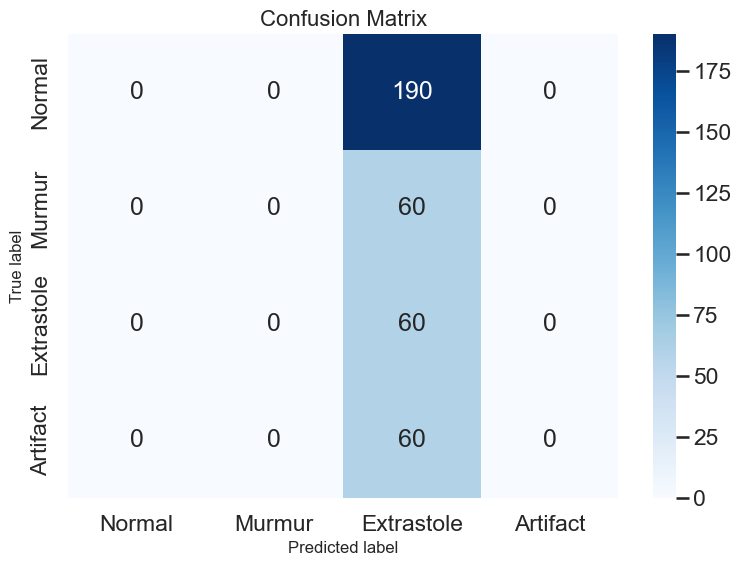

Saved: /Users/swarup/Downloads/heart_app/static/report_images/confusion_matrix.png


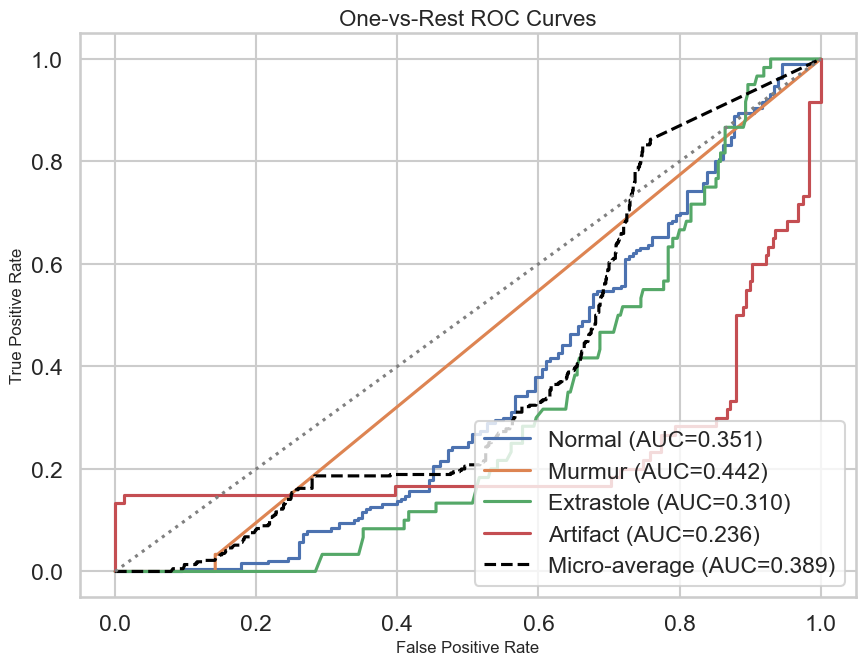

Saved: /Users/swarup/Downloads/heart_app/static/report_images/roc_curve.png


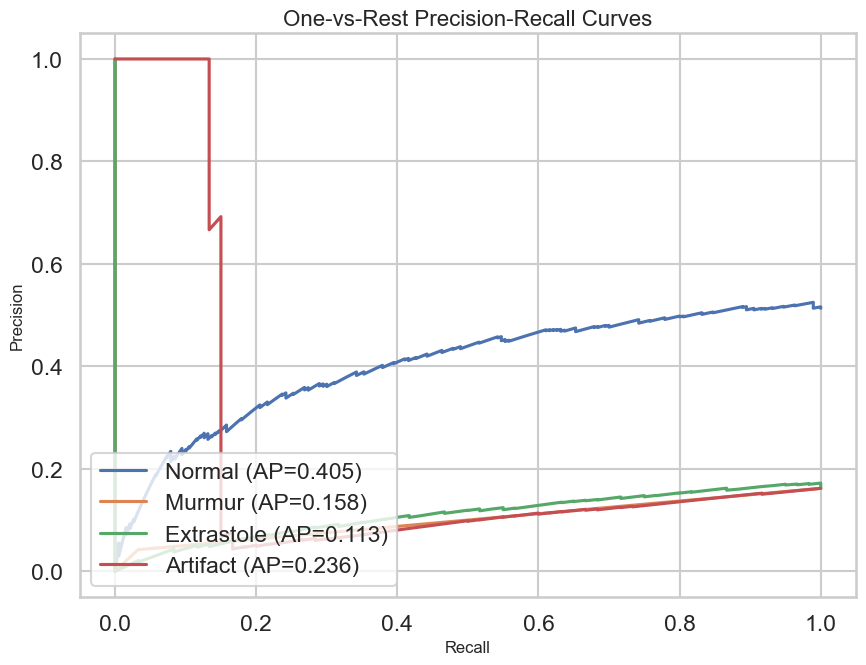

Saved: /Users/swarup/Downloads/heart_app/static/report_images/precision_recall_curve.png


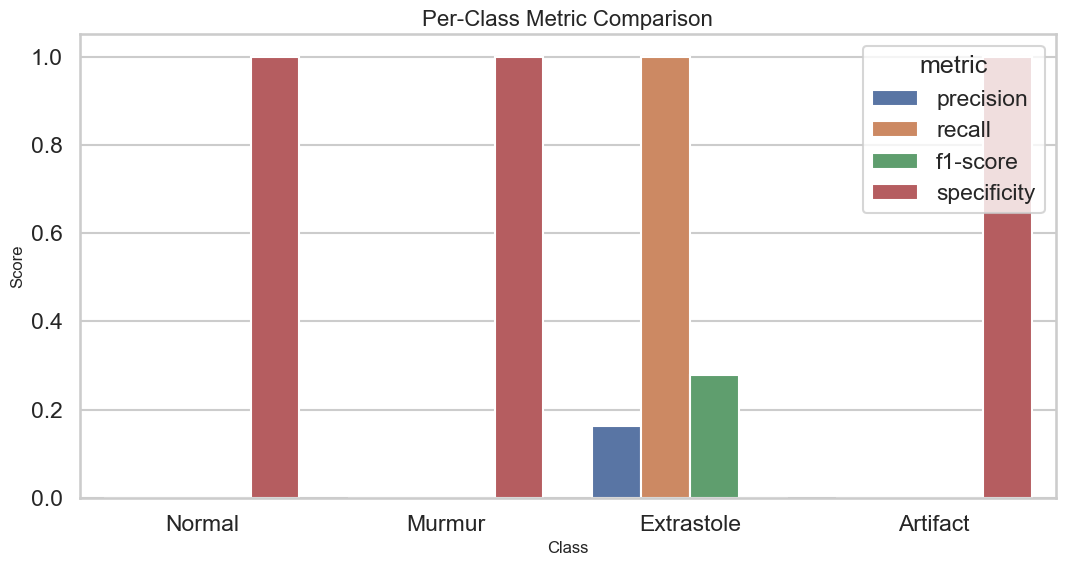

Saved: /Users/swarup/Downloads/heart_app/static/report_images/per_class_metrics.png


In [9]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS,
    ax=ax,
)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
cm_path = REPORT_DIR / "confusion_matrix.png"
fig.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {cm_path}")

# ROC curves
fig, ax = plt.subplots(figsize=(9, 7))
for idx, label in enumerate(LABELS):
    fpr, tpr, _ = roc_curve(y_true_bin[:, idx], prob_matrix[:, idx])
    auc_value = roc_auc_score(y_true_bin[:, idx], prob_matrix[:, idx])
    ax.plot(fpr, tpr, label=f"{label} (AUC={auc_value:.3f})")

micro_fpr, micro_tpr, _ = roc_curve(y_true_bin.ravel(), prob_matrix.ravel())
micro_auc = roc_auc_score(y_true_bin, prob_matrix, average="micro", multi_class="ovr")
ax.plot(micro_fpr, micro_tpr, linestyle="--", color="black", label=f"Micro-average (AUC={micro_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle=":", color="gray")
ax.set_title("One-vs-Rest ROC Curves")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
roc_path = REPORT_DIR / "roc_curve.png"
fig.savefig(roc_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {roc_path}")

# Precision-recall curves
fig, ax = plt.subplots(figsize=(9, 7))
for idx, label in enumerate(LABELS):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, idx], prob_matrix[:, idx])
    ap_score = average_precision_score(y_true_bin[:, idx], prob_matrix[:, idx])
    ax.plot(recall, precision, label=f"{label} (AP={ap_score:.3f})")

ax.set_title("One-vs-Rest Precision-Recall Curves")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left")
plt.tight_layout()
pr_path = REPORT_DIR / "precision_recall_curve.png"
fig.savefig(pr_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {pr_path}")

# Per-class metric comparison
plot_df = summary_table[["precision", "recall", "f1-score", "specificity"]].reset_index().rename(columns={"index": "class"})
plot_df = plot_df.melt(id_vars="class", var_name="metric", value_name="score")
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=plot_df, x="class", y="score", hue="metric", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Per-Class Metric Comparison")
ax.set_xlabel("Class")
ax.set_ylabel("Score")
plt.tight_layout()
bar_path = REPORT_DIR / "per_class_metrics.png"
fig.savefig(bar_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {bar_path}")

## 5. Visualize Class Distribution, Feature Correlation, and Explainability

For an audio pipeline, feature correlation is shown with engineered acoustic descriptors, and interpretability is reinforced with Grad-CAM examples. This gives the report both dataset-level and sample-level insight.

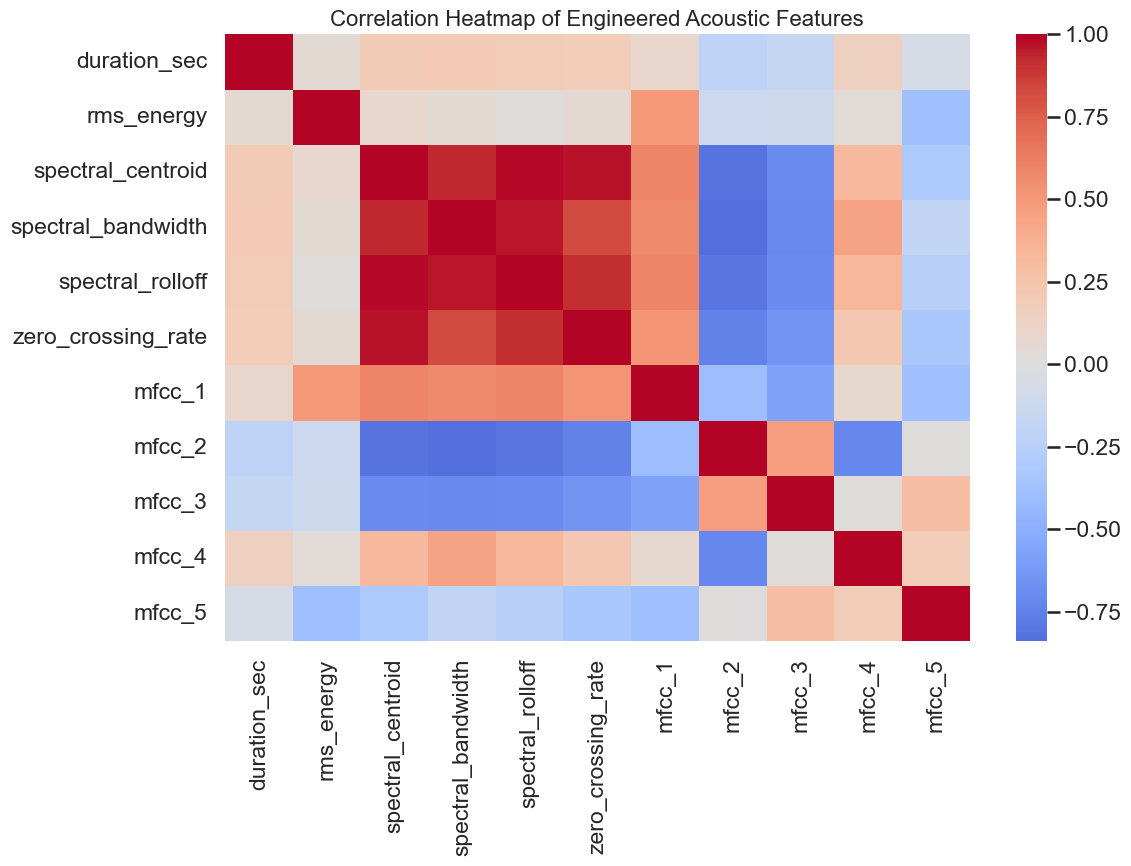

Saved: /Users/swarup/Downloads/heart_app/static/report_images/feature_correlation_heatmap.png


,Deep CNN + Transformer,Logistic Regression Baseline
accuracy,0.162162,0.648649
precision_macro,0.040541,0.626466
recall_macro,0.250000,0.472588
f1_macro,0.069767,0.440853
roc_auc_ovr_macro,0.334556,0.756939
binary_accuracy,0.486486,NaN
binary_precision,0.486486,NaN
binary_recall,1.000000,NaN
binary_f1,0.654545,NaN
binary_roc_auc,0.663713,NaN


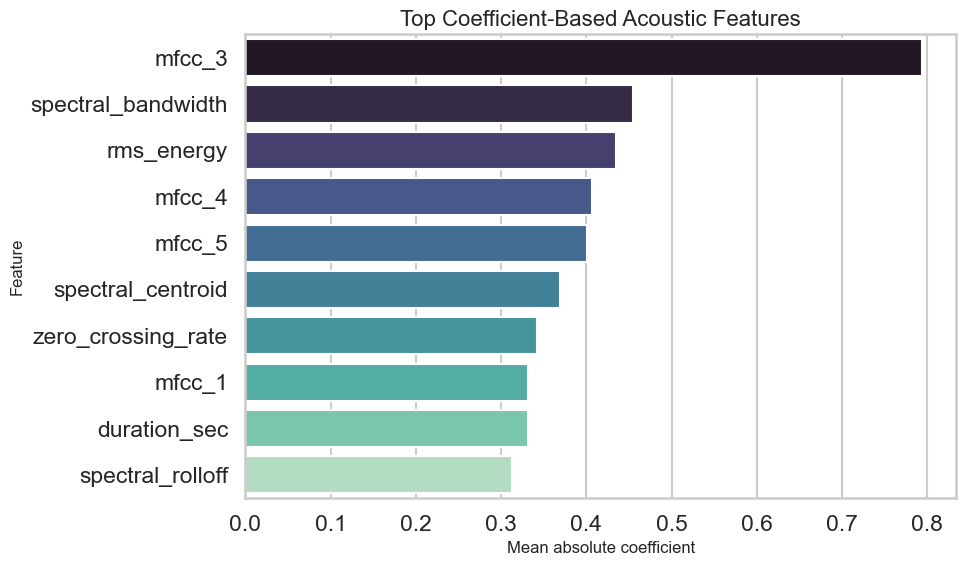

Saved: /Users/swarup/Downloads/heart_app/static/report_images/feature_importance.png


In [11]:
def extract_acoustic_features(file_path):
    y, sr = librosa.load(str(file_path), sr=22050)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=5)
    return {
        "duration_sec": len(y) / sr,
        "rms_energy": float(np.mean(librosa.feature.rms(y=y))),
        "spectral_centroid": float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))),
        "spectral_bandwidth": float(np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))),
        "spectral_rolloff": float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))),
        "zero_crossing_rate": float(np.mean(librosa.feature.zero_crossing_rate(y))),
        "mfcc_1": float(np.mean(mfcc[0])),
        "mfcc_2": float(np.mean(mfcc[1])),
        "mfcc_3": float(np.mean(mfcc[2])),
        "mfcc_4": float(np.mean(mfcc[3])),
        "mfcc_5": float(np.mean(mfcc[4])),
    }

feature_rows = []
for item in test_df.itertuples(index=False):
    row = extract_acoustic_features(item.path)
    row["label"] = item.label
    row["label_idx"] = LABEL_TO_INDEX[item.label]
    row["path"] = item.path
    feature_rows.append(row)

feature_df = pd.DataFrame(feature_rows)
feature_columns = [col for col in feature_df.columns if col not in {"label", "label_idx", "path"}]

corr_matrix = feature_df[feature_columns].corr()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Correlation Heatmap of Engineered Acoustic Features")
plt.tight_layout()
corr_path = REPORT_DIR / "feature_correlation_heatmap.png"
fig.savefig(corr_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {corr_path}")

# Interpretable classical baseline for coefficient-based feature importance
X = feature_df[feature_columns]
y = feature_df["label_idx"]
X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

baseline_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
)
baseline_model.fit(X_train_feat, y_train_feat)
baseline_pred = baseline_model.predict(X_test_feat)
baseline_prob = baseline_model.predict_proba(X_test_feat)

baseline_true_bin = label_binarize(y_test_feat.to_numpy(), classes=list(range(len(LABELS))))
baseline_cm = confusion_matrix(y_test_feat, baseline_pred, labels=list(range(len(LABELS))))
baseline_spec = {}
total_baseline = baseline_cm.sum()
for idx, label in enumerate(LABELS):
    tp = baseline_cm[idx, idx]
    fp = baseline_cm[:, idx].sum() - tp
    fn = baseline_cm[idx, :].sum() - tp
    tn = total_baseline - tp - fp - fn
    baseline_spec[label] = tn / (tn + fp) if (tn + fp) else np.nan

baseline_metrics = {
    "accuracy": accuracy_score(y_test_feat, baseline_pred),
    "precision_macro": precision_score(y_test_feat, baseline_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test_feat, baseline_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test_feat, baseline_pred, average="macro", zero_division=0),
    "roc_auc_ovr_macro": roc_auc_score(baseline_true_bin, baseline_prob, average="macro", multi_class="ovr"),
}

baseline_metrics_df = pd.DataFrame([baseline_metrics], index=["Logistic Regression Baseline"])
comparison_table = pd.concat(
    [
        metrics_df.rename(index={0: "Deep CNN + Transformer"}),
        baseline_metrics_df,
    ],
    axis=0,
)
display(comparison_table.T)

coef_model = baseline_model.named_steps["logisticregression"]
coef_importance = np.mean(np.abs(coef_model.coef_), axis=0)
importance_df = pd.DataFrame({"feature": feature_columns, "importance": coef_importance}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x="importance", y="feature", palette="mako", ax=ax)
ax.set_title("Top Coefficient-Based Acoustic Features")
ax.set_xlabel("Mean absolute coefficient")
ax.set_ylabel("Feature")
plt.tight_layout()
importance_path = REPORT_DIR / "feature_importance.png"
fig.savefig(importance_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {importance_path}")

## 6. Save Metrics and Generate Grad-CAM Examples

The final report should keep both numeric results and visual explanations. This section exports tables and figures and also captures a few Grad-CAM examples so the report can show exactly what regions of the spectrogram the model highlights.

In [12]:
# Save the core tables for reporting
metrics_df.to_csv(REPORT_DIR / "deep_model_metrics.csv", index=False)
summary_table.to_csv(REPORT_DIR / "deep_model_class_report.csv")
comparison_table.to_csv(REPORT_DIR / "model_comparison_table.csv")
feature_df.to_csv(REPORT_DIR / "engineered_features.csv", index=False)

# Save a binary vs multiclass metrics summary too
binary_report = pd.DataFrame(
    {
        "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
        "score": [
            metrics_summary["binary_accuracy"],
            metrics_summary["binary_precision"],
            metrics_summary["binary_recall"],
            metrics_summary["binary_f1"],
            metrics_summary["binary_roc_auc"],
        ],
    }
)
binary_report.to_csv(REPORT_DIR / "binary_metrics.csv", index=False)

# Grad-CAM examples for one representative file from each class
for label in LABELS:
    sample_row = test_df[test_df["label"] == label].iloc[0]
    sample_input = preprocess_audio(str(sample_row.path))
    conv_layer_name = get_last_conv_layer_name(binary_model)
    heatmap = get_gradcam(binary_model, sample_input, conv_layer_name)
    output_path = REPORT_DIR / f"gradcam_{label.lower()}.png"
    save_superimposed_gradcam(sample_input, heatmap, output_path=str(output_path))
    print(f"Saved: {output_path}")

print(f"All report metrics and figures have been saved to: {REPORT_DIR}")

🔍 DEBUG - Target Audio Spectrogram Dimensions: 130x128 (WxH)
🔍 DEBUG - Raw Conv Feature Map Shape: (64, 65)
🔍 DEBUG - Final Resized Heatmap Shape: (128, 130)
✅ SUCCESS - Grad-CAM saved successfully to /Users/swarup/Downloads/heart_app/static/report_images/gradcam_normal.png
Saved: /Users/swarup/Downloads/heart_app/static/report_images/gradcam_normal.png
🔍 DEBUG - Target Audio Spectrogram Dimensions: 130x128 (WxH)
🔍 DEBUG - Raw Conv Feature Map Shape: (64, 65)
🔍 DEBUG - Final Resized Heatmap Shape: (128, 130)
✅ SUCCESS - Grad-CAM saved successfully to /Users/swarup/Downloads/heart_app/static/report_images/gradcam_murmur.png
Saved: /Users/swarup/Downloads/heart_app/static/report_images/gradcam_murmur.png
🔍 DEBUG - Target Audio Spectrogram Dimensions: 130x128 (WxH)
🔍 DEBUG - Raw Conv Feature Map Shape: (64, 65)
🔍 DEBUG - Final Resized Heatmap Shape: (128, 130)
✅ SUCCESS - Grad-CAM saved successfully to /Users/swarup/Downloads/heart_app/static/report_images/gradcam_extrastole.png
Saved: /U

## 7. Interpretation Notes

- Accuracy gives the overall hit rate, but macro precision, recall, and F1-score are better at showing whether minority classes are being recognized consistently.
- Specificity is important when you want to know how well the model avoids false alarms for a class it should not predict.
- ROC-AUC summarizes separability across thresholds, while precision-recall curves are especially useful when one class is harder to detect than the others.
- The confusion matrix is the fastest way to see which heart sound classes are being confused, and the Grad-CAM examples help explain why those decisions were made visually.